# 실습 4-2 : Under/Over Sampling (AI4I 데이터 버전)

#### **<실습 내용>**

1. 클래스 불균형 데이터 확인
- t-SNE를 통한 시각화

2. Resampling 기법 적용
- Random Undersampling
- TomekLinks (Undersampling)
- SMOTE (Oversampling)
- SMOTE + TomekLinks (복합 Resampling)
- ADASYN (Oversampling)

3. Resampling 전후 T-SNE 및 성능 비교

## 분석 준비

### 주요 라이브러리 호출

In [2]:
# 실행해서 설치해주세요.
! pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.manifold import TSNE

from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### 데이터 불러오기

In [6]:
rawdata = pd.read_csv("dataset/day4-2_data.csv")
rawdata

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
data = pd.read_csv("dataset/day4-2_data.csv")

# 고장 유형 컬럼(TWF~RNF)은 Machine failure 여부와 직접 연관되어 정보 누수가 발생하므로 제거
data = data.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

# Type(범주형)은 원-핫 인코딩
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

print("데이터 크기:", data.shape)
print("결측치 수:", data.isnull().sum().sum())
data.head()

데이터 크기: (10000, 8)
결측치 수: 0


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


---

## 1) 클래스 불균형 확인

> **클래스 불균형(Class Imbalance)** 이란 정상 데이터의 양이 불량 데이터보다 훨씬 많은 상황을 의미함
> - 해결 기법: **Resampling** (Under/Over Sampling) 또는 **One-Class Learning Model**

In [7]:
X = data.drop(["Machine failure"], axis=1)  # 타겟 컬럼 제외한 나머지를 입력 변수로 사용
Y = data["Machine failure"]

In [8]:
print("클래스 분포:")
print(Y.value_counts())  # 클래스별 개수 확인

클래스 분포:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [9]:
print("클래스 비율:")
print(np.round(Y.value_counts(normalize=True), 3))  # 클래스별 비율 확인 (소수점 3자리)

클래스 비율:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


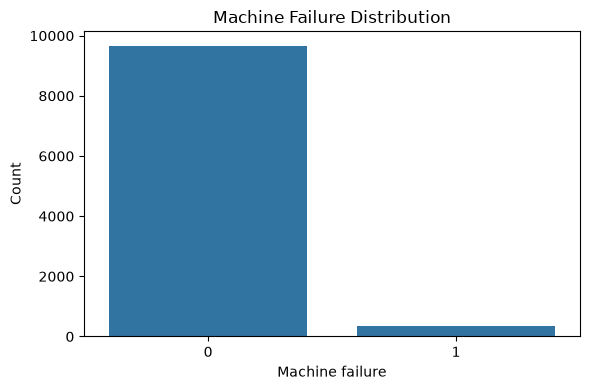

In [10]:
# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=Y.value_counts().index, y=Y.value_counts().values)  # 클래스별 개수를 막대그래프로 표시
plt.title("Machine Failure Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1-1) t-SNE를 통한 시각화

> **t-SNE**는 고차원 데이터를 2차원으로 매핑하여 시각화하는 기법임
> - 클래스 간 분리 정도를 시각적으로 확인할 수 있음
> - 분리가 잘 될수록 분류 모델이 두 클래스를 구분하기 쉬운 데이터라는 뜻임

In [11]:
# n_components=2 : 원래 수백 개 특성을 가진 데이터를 2차원 좌표(x, y)로 압축
# fit_transform(X) : X를 학습하면서 동시에 2차원 좌표로 변환

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
X_embedded

array([[ 19.805283, -61.13667 ],
       [-62.04681 , -55.326824],
       [ -6.066069, -65.997696],
       ...,
       [ 53.270756, -37.323063],
       [-53.86743 , -49.0759  ],
       [ -4.449764, -56.573914]], shape=(10000, 2), dtype=float32)

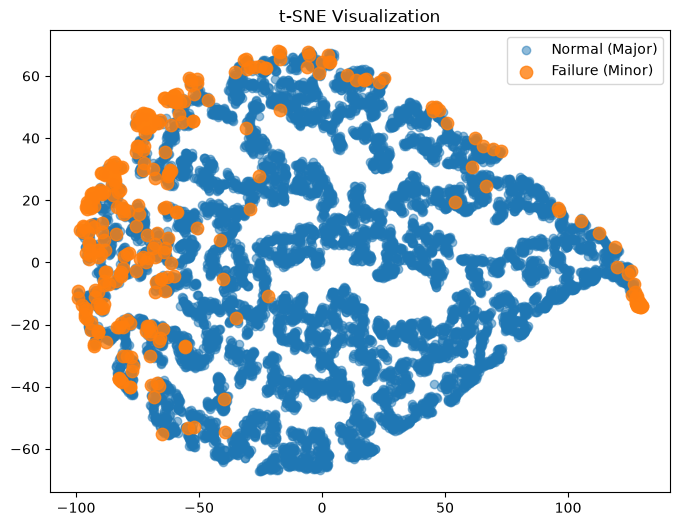

In [12]:
plt.figure(figsize=(8, 6))
# X_embedded[Y == 0, 0] : Normal 클래스(Y=0)의 x좌표, X_embedded[Y == 0, 1] : y좌표
plt.scatter(X_embedded[Y == 0, 0], X_embedded[Y == 0, 1], label='Normal (Major)', alpha=0.5)  # 다수 클래스(정상) 산점도
# X_embedded[Y == 1, 0] : Failure 클래스(Y=1)의 x좌표, X_embedded[Y == 1, 1] : y좌표
plt.scatter(X_embedded[Y == 1, 0], X_embedded[Y == 1, 1], label='Failure (Minor)', alpha=0.8, s=80)  # 소수 클래스(고장) 산점도, 점 크기 크게
plt.legend()
plt.title("t-SNE Visualization")
plt.show()

---

## 2) Resampling 기법 적용

| 기법 | 유형 | 설명 |
|---|---|---|
| TomekLinks | Undersampling | 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함 |
| SMOTE | Oversampling | 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄 |
| SMOTE + TomekLinks | 복합 Resampling | SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함 |
| ADASYN | Oversampling | SMOTE와 비슷하지만 구분이 어려운 샘플 주변에 더 많은 가상 샘플을 만들어냄 |

> Resampling은 **학습 데이터에만** 적용하고, 테스트 데이터는 원본 그대로 유지해야 함

In [ ]:
# test는 실제 환경과 동일한 불균형 상태를 유지해야 모델 성능을 제대로 평가할 수 있음. stratify 필수!

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("학습 데이터 클래스 분포:")
print(Y_train.value_counts())

학습 데이터 클래스 분포:
Machine failure
0    7729
1     271
Name: count, dtype: int64


### 2-1) TomekLinks (Undersampling)

> **Tomek Links**는 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함

In [14]:
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train, Y_train)  # TomekLinks로 다수 클래스 일부 제거 (undersampling)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_TomekLinks.value_counts()})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]  # 클래스별 변화량 계산
compare_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7641,-88
1,271,271,0


### 2-2) SMOTE (Oversampling)

> **SMOTE**는 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄

In [15]:
X_SMOTE, Y_SMOTE = SMOTE().fit_resample(X_train, Y_train)  # SMOTE로 소수 클래스를 다수 클래스 수만큼 늘림 (oversampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTE.value_counts()})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7729,7458


### 2-3) SMOTE + TomekLinks (복합 Resampling)

> SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함

In [16]:
X_SMOTETomek, Y_SMOTETomek = SMOTETomek().fit_resample(X_train, Y_train)  # SMOTE로 늘린 뒤 TomekLinks로 겹치는 샘플 정리 (복합 resampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTETomek.value_counts()})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7668,-61
1,271,7668,7397


### 2-4) ADASYN (Oversampling)

> **ADASYN**은 SMOTE를 개선한 기법으로, 다수 클래스와 인접한 소수 클래스 샘플 주변에 더 많은 데이터를 생성함
> - 즉 분류가 어려운 경계 영역에 집중적으로 데이터를 증강함

In [17]:
X_ADASYN, Y_ADASYN = ADASYN(random_state=42).fit_resample(X_train, Y_train)  # ADASYN으로 소수 클래스를 다수 클래스 수만큼 늘림 (경계 근처에 더 많이 생성)

# 적용 전/후 클래스별 개수 비교
compare_ADA = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_ADASYN.value_counts()})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]  # 클래스별 변화량 계산
compare_ADA

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7671,7400


> 기본 설정 기준: `sampling_strategy ='auto'`
> - 1:1이 되는 기법: SMOTE, SMOTE+TomekLinks
> - 1:1이 아닌 기법: TomekLinks (다수 클래스 일부만 제거), ADASYN (경계 근처 위주로 생성되어 정확히 1:1은 아님)

---

## 3) Resampling 결과 분석

### 3-1) Sampling 전후 t-SNE 비교

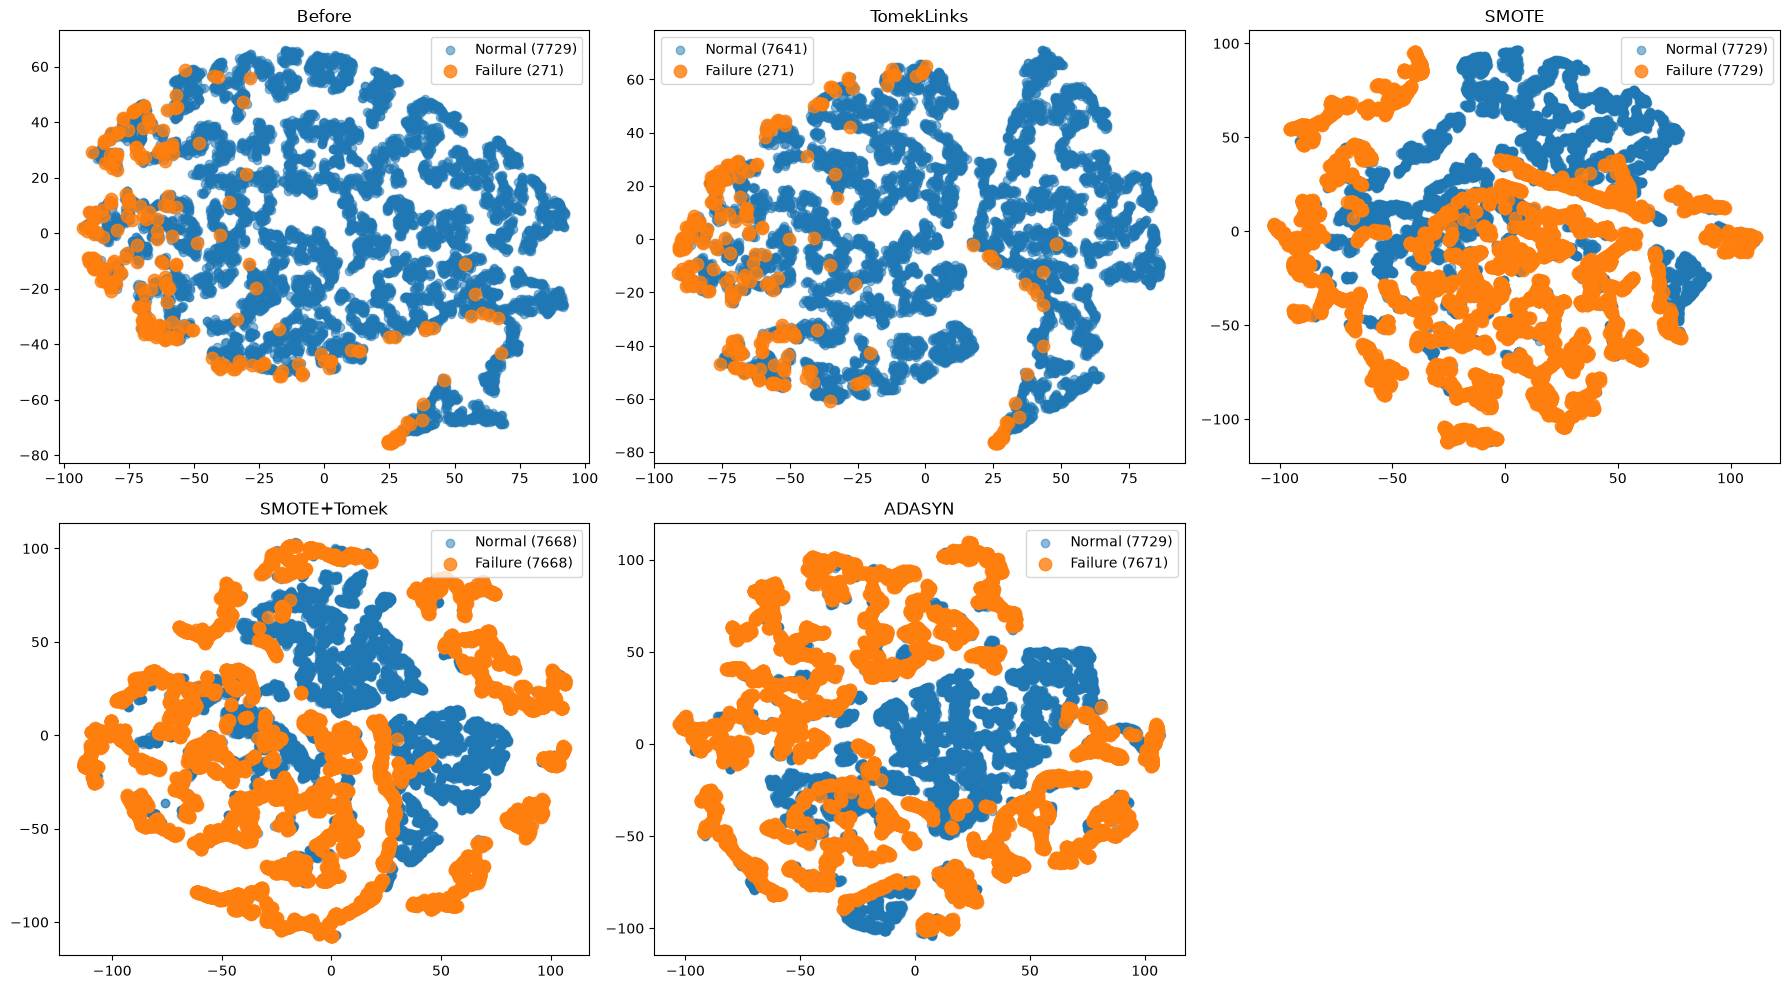

In [18]:
# 방법론별 t-SNE 비교 (Normal vs Failure)
A, B = 0, 1  # Normal, Failure

sampling_datasets = {
    "Before": (X_train, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s.values == A, 0], emb[Y_s.values == A, 1], label=f'Normal ({(Y_s==A).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s.values == B, 0], emb[Y_s.values == B, 1], label=f'Failure ({(Y_s==B).sum()})', alpha=0.8, s=80)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 3-2) Sampling 전후 성능 비교

In [19]:
from xgboost import XGBClassifier

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():

    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos  # 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)
    results.append({
        "Method": name,
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4)
    })

pd.DataFrame(results)

,Method,Precision,Recall,F1-score
0,Before,0.7391,0.7500,0.7445
1,TomekLinks,0.6795,0.7794,0.7260
2,SMOTE,0.5824,0.7794,0.6667
3,SMOTE+Tomek,0.6087,0.8235,0.7000
4,ADASYN,0.6022,0.8235,0.6957


---

## 4) Vibe Coding 실습

**[과제 1]**
지수는 위 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)를 보고, Resampling 기법마다 Normal과 Failure 클래스가 어떻게 다르게 분포하는지 궁금해졌습니다.

AI에게 이미지를 보여주며 각 기법의 결과가 어떤 의미를 갖는지 해석을 요청하고 원본 데이터에서 Failure 데이터가 339개(전체의 3.4%)뿐이라는 점을 함께 고려했을 때 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합할지 AI와 논의해 보세요.

[프롬프트]
[캡쳐이미지] 이것은 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)야.
1. 각 기법의 결과가 어떤 의미를 갖는지 중학생을 대하는 선생님처럼 설명해줘.
2. 원본 데이터에 Failure 데이터가 339개(전체의 3.4%)뿐이야. 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합한거야?

[AI의 대답]

## 1. t-SNE 그림을 중학생에게 설명한다면

먼저 **t-SNE는 "고차원 데이터를 2D 지도에 그려 보는 것"**입니다. 점들 사이의 **정확한 거리**보다 **"뭉치는 패턴"**을 보는 그림이라고 생각하면 됩니다.

- **파란 점 (Normal)** = 정상 기계
- **주황 점 (Failure)** = 고장 난 기계

---

### Before (적용 전)

> "반에 학생 100명 중, 고장 난 기계는 3명뿐인 상황"

- 파란 점이 압도적으로 많고, 주황 점은 **여기저기 흩어져** 있습니다.
- 고장 데이터가 **한곳에 모여 있지 않고**, 정상 데이터 **안에 섞여** 있습니다.
- 그래서 모델 입장에서는 "고장은 정말 드물고, 정상이랑 비슷하게 보이는 경우도 많다"는 느낌입니다.

---

### TomekLinks (언더샘플링)

> "정상과 고장이 **너무 붙어 있는** 정상 데이터만 살짝 걷어내기"

- 주황 점 수는 그대로 (**271개**), 파란 점만 조금 줄었습니다 (**7729 → 7641**).
- 경계에 애매하게 걸쳐 있는 **정상 샘플**을 제거해, **경계를 조금 더 선명하게** 만듭니다.
- 데이터 양은 거의 유지하면서 "헷갈리는 정상"만 정리하는 **가장 부드러운** 방법입니다.

---

### SMOTE (오버샘플링)

> "고장 데이터가 너무 적으니, 기존 고장 점 **사이사이에 가짜 고장 점**을 많이 만들기"

- 주황 점이 **271 → 7729**로 크게 늘었습니다. (1:1 균형)
- 주황 점들이 **뭉친 덩어리**처럼 보이는데, 이건 **실제로 그렇게 많았던 게 아니라** SMOTE가 **새로 만든 점**입니다.
- 장점: 모델이 고장을 더 자주 보게 됨 → **Recall(고장 찾기)** 은 올라갈 수 있음
- 단점: 원래 없던 고장 패턴을 만들어 낼 수 있어, 그림이 **인위적으로 빽빽**해 보입니다.

---

### SMOTE + Tomek (복합)

> "가짜 고장을 만든 다음, 다시 애매하게 겹치는 점들을 정리하기"

- SMOTE로 균형을 맞춘 뒤, TomekLinks로 **경계가 애매한 점**을 다시 정리합니다.
- 순수 SMOTE보다 **겹침이 조금 덜해** 보이고, 클래스 수도 **7668 : 7668**로 거의 1:1입니다.
- "균형 + 경계 정리"를 동시에 노린 방법입니다.

---

### ADASYN (오버샘플링)

> "고장이 **특히 적고 헷갈리는 구역**에 가짜 고장을 더 많이 만들기"

- SMOTE와 비슷하지만, **정상(파란 점)과 가까운 곳**에 주황 점을 **더 집중**해서 만듭니다.
- 그래서 **7671개**로 거의 1:1이지만, SMOTE만큼 완벽히 같지는 않습니다.
- "어려운 구역을 더 공부시키는" 방식이라, **경계 근처**에 주황 점이 더 많아 보입니다.

---

### 한 줄 요약

| 그림 | 한 줄 해석 |
|------|-----------|
| **Before** | 고장은 극소수이고 정상 안에 섞여 있음 |
| **TomekLinks** | 정상만 조금 줄여 경계를 정리 (가장 보수적) |
| **SMOTE** | 가짜 고장을 대량 생성해 1:1 균형 |
| **SMOTE+Tomek** | 균형 맞춘 뒤 겹치는 점 정리 |
| **ADASYN** | 헷갈리는 구역에 가짜 고장을 더 많이 생성 |

---

## 2. Failure 339개(3.4%) — Resampling vs One-Class Learning?

### 결론부터

**이 문제에는 One-Class Learning 쪽이 더 적합합니다.** 다만 Resampling을 **보조**로 쓰는 건 가능합니다.

---

### 이유

**① 불균형이 매우 심함 (3.4%)**

- 고장은 전체의 약 1/30입니다.
- "고장 vs 정상을 둘 다 골고루 배우자"보다, **"정상이 어떤 모습인지 먼저 배우고, 그와 다른 걸 고장으로 본다"**는 One-Class 관점이 자연스럽습니다.

**② t-SNE에서 고장이 정상 안에 섞여 있음**

- Before 그림에서 주황 점이 파란 점 **한가운데** 흩어져 있습니다.
- 고장이 **따로 뭉쳐 있지 않아**, SMOTE/ADASYN이 만든 **인위적인 주황 덩어리**는 실제 분포와 다를 수 있습니다.

**③ 실제 고장 샘플이 339개뿐**

- SMOTE는 271개(학습셋)에서 **수천 개의 가짜 고장**을 만듭니다.
- 진짜 고장 패턴이 충분하지 않은데 가짜를 많이 넣으면, **지나치게 학습(overfitting)** 될 위험이 큽니다.

**④ 노트북 성능 결과도 힌트**

| Method | F1 | Recall |
|--------|-----|--------|
| Before | **0.7445** | 0.75 |
| TomekLinks | 0.7260 | 0.78 |
| SMOTE | 0.6667 | 0.78 |
| SMOTE+Tomek | 0.70 | **0.82** |
| ADASYN | 0.70 | **0.82** |

- Resampling이 **전체 성능(F1)을 꼭 올려주지는 않음**
- SMOTE/ADASYN은 Recall은 올리지만 **Precision이 떨어짐** (고장이라고 했는데 아닌 경우 증가)

---

### 각 접근을 비유하면

| 접근 | 비유 |
|------|------|
| **Resampling** | 소수인 고장 학생에게 **가짜 시험지**를 많이 만들어 주는 것 |
| **One-Class Learning** | 정상 기계만 보고 **"평소와 다른 것 = 이상"** 이라고 판단하는 것 |

공장 고장 예측처럼 **고장이 드물고**, **정상 패턴이 주류**인 문제는 후자가 더 잘 맞는 경우가 많습니다.

---

### 실무적으로 추천하는 순서

1. **1순위: One-Class Learning** (SVDD, Isolation Forest, One-Class SVM 등) → "정상만 학습 → 이상 탐지" 프레이밍
2. **2순위: Resampling 없이 `class_weight` 조정** → 가짜 데이터 없이 고장 클래스에 가중치만 줌
3. **3순위: 가벼운 Resampling (TomekLinks)** → 데이터 손실이 적고 경계만 정리
4. **신중히: SMOTE / ADASYN** → Recall이 꼭 필요할 때만, 그리고 **검증 성능**을 꼭 확인

---

### 과제용 한 줄 정리

> Failure가 339개(3.4%)로 매우 적고, t-SNE에서도 정상과 고장이 많이 겹치므로 **One-Class Learning이 더 적합**하다. Resampling은 고장을 인위적으로 늘리기 때문에 이 데이터에서는 **보조 수단**으로만 쓰는 것이 좋다.
